In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

## monte carlo method

In [2]:
# ep gen function
def generate_episode(env):
    # init ep list
    episode = []

    # reset env
    state, info = env.reset()
    terminated = False

    # iter until terminated
    while not terminated:
        # select random action
        action = env.action_space.sample()
        # execute step
        next_state, action, reward, terminated, truncated, info = env.step(action)
        # update ep data
        episode.append((state, action, reward))
        state = next_state

    return episode

# ex usage
# print(generate_episode())

In [ ]:
# Q = np.zeros((num_states, num_actions))
# returns_sum = np.zeros((num_states, num_actions))
# returns_count = np.zeros((num_states, num_actions))

In [ ]:
# Implementing first-visit Monte Carlo function
def first_visit_mc(num_episodes, num_states, num_actions, env):
    # init np arrays
    Q = np.zeros((num_states, num_actions))
    returns_sum = np.zeros((num_states, num_actions))
    returns_count = np.zeros((num_states, num_actions))

    # iter eps
    for i in range(num_episodes):
        episode = generate_episode(env=env)
        visited_states = set()
        for j, (state, action, reward) in enumerate(episode):
            # define first visit condition
            if (state, action) not in visited_states:
                # update returns, counts and visited states
                returns_sum[state, action] += sum([x[2] for x in episode[j:]])
                returns_count[state, action] += 1
                visited_states.add((state, action))
    
    non_zero_counts = returns_count != 0
    Q[non_zero_counts] = returns_sum[non_zero_counts] / returns_count[non_zero_counts]

    return Q

In [ ]:
# Implementing every-visit Monte Carlo function
def every_visit_mc(num_episodes, num_states, num_actions, env):
    # init np arrays
    Q = np.zeros((num_states, num_actions))
    returns_sum = np.zeros((num_states, num_actions))
    returns_count = np.zero((num_states, num_actions))

    # iter eps
    for i in range(num_episodes):
        episode = generate_episode(env=env)
        for j, (state, action, reward) in enumerate(episode):
            returns_sum[state, action] += sum([x[2] for x in episode[j:]])
            returns_count[state, action] += 1

    non_zero_counts = returns_count != 0
    Q[non_zero_counts] = returns_sum[non_zero_counts] / returns_count[non_zero_counts]

    return Q

## temporal difference learning

### init env

In [16]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)

In [19]:
def get_policy(num_states, num_actions):
    policy = {s: 0 for s in range(num_states-1)}
    
    for state in range(num_states):
        max_action = max(range(num_actions), key=lambda action: Q[(state, action)])
        policy[state] = max_action

    return policy

In [20]:
def render():
    state_image = env.render()
    plt.imshow(state_image)
    plt.axis('off')
    plt.show()

In [21]:
def render_policy(policy):
  state, info = env.reset()
  terminated = False
  render()
  while not terminated:
    # Select action based on policy 
    action = policy[state]
    state, reward, terminated, truncated, info = env.step(action)
    # Render the environment
    render()

In [22]:
# Implementing the SARSA update rule function
def update_q_table(state, action, reward, next_state, next_action, Q, alpha, gamma):
    # get old value of current (state, action)
    old_value = Q[state, action]
    # get value of next (state, action)
    next_value = Q[next_state, next_action]
    # compute new value of current (state, action)
    Q[(state, action)] = (1-alpha) * old_value + alpha * (reward + gamma * next_value)

    return Q

In [23]:
# # ex usage
# alpha = 0.1
# gamma  = 0.8
# Q = np.array([[10,0],[0,20]], dtype='float32')
# # Update the Q-table for the ('state1', 'action1') pair
# Q = update_q_table(state=0, action=0, reward=5, next_state=1, next_action=1)
# print(Q)

In [24]:
num_states = env.observation_space.n
num_actions = env.action_space.n
Q = np.zeros((num_states, num_actions))
ALPHA = 0.1
GAMMA = 1
NUM_EPISODES = 1000

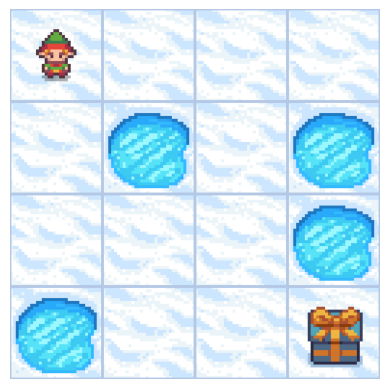

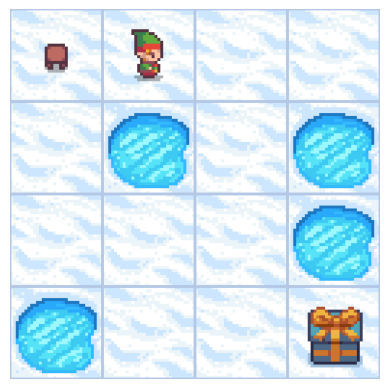

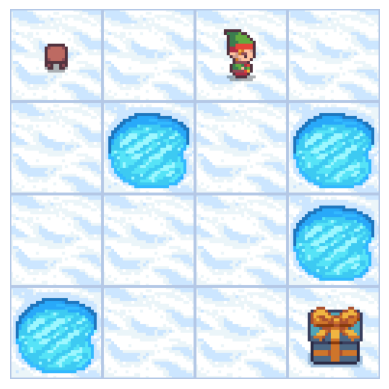

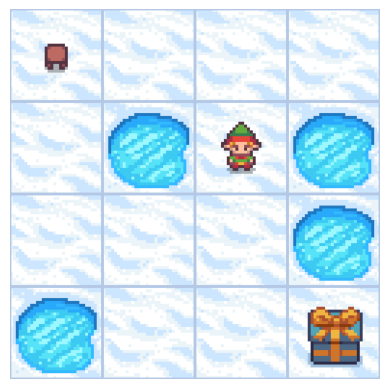

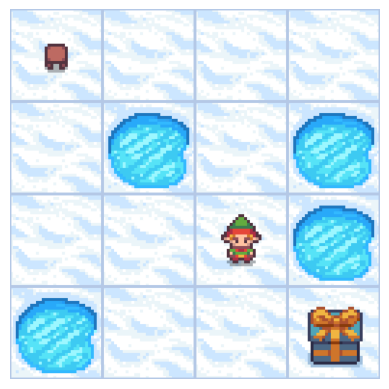

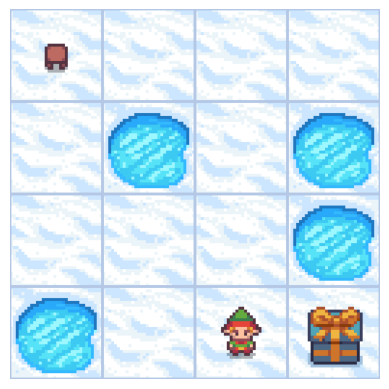

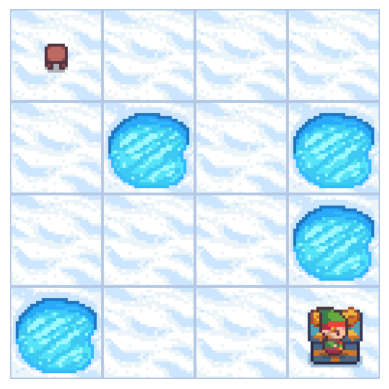

: 

In [ ]:
for episode in range(NUM_EPISODES):
    state, action = env.reset()
    # randomly select action
    action = env.action_space.sample()
    terminated = False
    while not terminated:
        # execute action
        next_state, reward, terminated, truncated, info = env.step(action)
        # choose next action randomly
        next_action = env.action_space.sample()
        # update Q-table
        Q = update_q_table(state=state, action=action, reward=reward, next_state=next_state, next_action=next_action, Q=Q, alpha=ALPHA, gamma=GAMMA)
        state, action = next_state, next_action
render_policy(get_policy(num_states=num_states, num_actions=num_actions))

## Q-learning

In [5]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)

In [6]:
def get_policy(num_states, num_actions):
    policy = {s: 0 for s in range(num_states-1)}
    
    for state in range(num_states):
        max_action = max(range(num_actions), key=lambda action: Q[(state, action)])
        policy[state] = max_action

    return policy

In [7]:
def render():
    state_image = env.render()
    plt.imshow(state_image)
    plt.axis('off')
    plt.show()

In [8]:
def render_policy(policy):
  state, info = env.reset()
  terminated = False
  render()
  while not terminated:
    # Select action based on policy 
    action = policy[state]
    state, reward, terminated, truncated, info = env.step(action)
    # Render the environment
    render()

In [9]:
def update_q_table_qlearning(state, action, reward, next_state, Q, alpha, gamma):
    # get old value of current (state, action)
    old_value = Q[state, action]
    # get value of next (state, action)
    max_value = max(Q[next_state])
    # compute new value of current (state, action)
    Q[state, action] = (1 - alpha) * old_value + alpha * (reward + gamma * max_value)

    return Q

In [10]:
policy = {0: 3,
 1: 3,
 2: 3,
 3: 3,
 4: 3,
 5: 2,
 6: 2,
 7: 2,
 8: 3,
 9: 3,
 10: 3,
 11: 3,
 12: 2,
 13: 1,
 14: 2,
 15: 1,
 16: 3,
 17: 0,
 18: 0,
 19: 0,
 20: 2,
 21: 3,
 22: 2,
 23: 0,
 24: 3,
 25: 3,
 26: 3,
 27: 3,
 28: 3,
 29: 0,
 30: 2,
 31: 1,
 32: 3,
 33: 3,
 34: 3,
 35: 0,
 36: 3,
 37: 2,
 38: 1,
 39: 1,
 40: 2,
 41: 0,
 42: 0,
 43: 3,
 44: 2,
 45: 0,
 46: 0,
 47: 2,
 48: 0,
 49: 0,
 50: 2,
 51: 0,
 52: 0,
 53: 0,
 54: 0,
 55: 1,
 56: 0,
 57: 0,
 58: 0,
 59: 0,
 60: 2,
 61: 0,
 62: 3,
 63: 0}

In [13]:
num_states = env.observation_space.n
num_actions = env.action_space.n
Q = np.zeros((num_states, num_actions))
ALPHA = 0.1
GAMMA = 1
NUM_EPISODES = 10

In [20]:
# NOTE: FIX BELONG NEED TO GET Q LEARNING vs RANDOM SAMPLING

In [19]:
# reward_per_learned_episode = []

# for episode in range(NUM_EPISODES):
#     state, info = env.reset()
#     total_reward = 0
#     terminated = False
#     while not terminated:
#         action = env.action_space.sample()
#         # Execute the action
#         next_state, reward, terminated, truncated, info = env.step(action)
#         # Update the Q-table
#         update_q_table(state, action, reward, next_state)
#         state = next_state
#         total_reward += reward
#     # Append the total reward to the rewards list    
#     rewards_per_episode.append(total_reward)
# print("Average reward per random episode: ", np.mean(rewards_per_episode))

In [18]:
# reward_per_learned_episode = []

# policy = get_policy(num_states=num_states, num_actions=num_actions)
# for i in range(NUM_EPISODES):
#     if i % 2 == 0:
#         print("EPISODE: ", i)
#     state, info = env.reset()
#     terminated = False
#     episode_reward = 0
#     while not terminated:
#         # select best action based on learned Q-table
#         action = policy[state]
#         #take action and observe next state
#         new_state, reward, terminated, truncated, info = env.step(action)
#         state = new_state
#         episode_reward += reward
#     reward_per_learned_episode.append(episode_reward)

In [ ]:
for episode in range(10000):
    state, info = env.reset()
    total_reward = 0
    terminated = False
    while not terminated:
        action = env.action_space.sample()
        # Execute the action
        next_state, reward, terminated, truncated, info = env.step(action)
        # Update the Q-table
        update_q_table(state, action, reward, next_state) 
        state = next_state
        total_reward += reward
    # Append the total reward to the rewards list    
    rewards_per_episode.append(total_reward)
print("Average reward per random episode: ", np.mean(rewards_per_episode))

In [ ]:
for episode in range(10000):
    state, info = env.reset()
    terminated = False
    episode_reward = 0
    while not terminated:
        # Select the best action based on learned Q-table
        action = np.argmax(Q[state])
        new_state, reward, terminated, truncated, info = env.step(action)
        state = new_state
        episode_reward += reward
    reward_per_learned_episode.append(episode_reward)
# Compute and print the average reward per learned episode
avg_reward_per_learned_episode = np.mean(reward_per_learned_episode)
print("Average reward per learned episode: ", avg_reward_per_learned_episode)
print("Average reward per random episode: ", avg_reward_per_random_episode)

In [ ]:
avg_reward_per_random_episode = 0.0021

In [ ]:
# Compute and print the average reward per learned episode
avg_reward_per_learned_episode = np.mean(reward_per_learned_episode)
print("Average reward per learned episode: ", avg_reward_per_learned_episode)
print("Average reward per random episode: ", avg_reward_per_random_episode)